In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from loader import load_dataset
import scipy.stats as stats

In [ ]:
#Iz razloga koje ćemo proći tek kasnije, posmatraćemo podatke na dnevnom nivou, umesto iz sata u sat
df = load_dataset('1d')

In [ ]:
#Pregled podataka

df.info()
print(df.head())
print(len(df))

<class 'pandas.DataFrame'>
RangeIndex: 1662 entries, 0 to 1661
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  1662 non-null   int64         
 1   open       1662 non-null   float64       
 2   high       1662 non-null   float64       
 3   low        1662 non-null   float64       
 4   close      1662 non-null   float64       
 5   volume     1662 non-null   float64       
 6   date       1662 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 91.0 KB
       timestamp      open      high       low     close       volume  \
0  1640995200000  46216.93  47954.63  46208.37  47722.65  19604.46325   
1  1641081600000  47722.66  47990.00  46654.00  47286.18  18340.46040   
2  1641168000000  47286.18  47570.00  45696.00  46446.10  27662.07710   
3  1641254400000  46446.10  47557.54  45500.00  45832.01  35491.41360   
4  1641340800000  45832.01  47070.00  42500.00 

In [ ]:
#Gledanje prvog i poslednjeg datuma koji smo povukli sa Binance Exchange

print(df['date'][0])
print(df['date'].iloc[-1])

2022-01-01 00:00:00
2026-07-20 00:00:00


In [ ]:
#Binance Exchange meri vreme u milisekundama. Proverićemo da li se svaki naš red koji posmatramo razlikuje za 86.400.000 milisekundi, 
#što je jednako jednom danu.

print(df['timestamp'].diff().iloc[1:].eq(86_400_000).all())

True


In [36]:
df['log_returns'] = np.log(df['close']).diff()
print(df['log_returns'])

0            NaN
1      -0.009188
2      -0.017926
3      -0.013310
4      -0.053346
          ...   
1657   -0.014404
1658    0.001588
1659    0.014019
1660   -0.001724
1661    0.011574
Name: log_returns, Length: 1662, dtype: float64


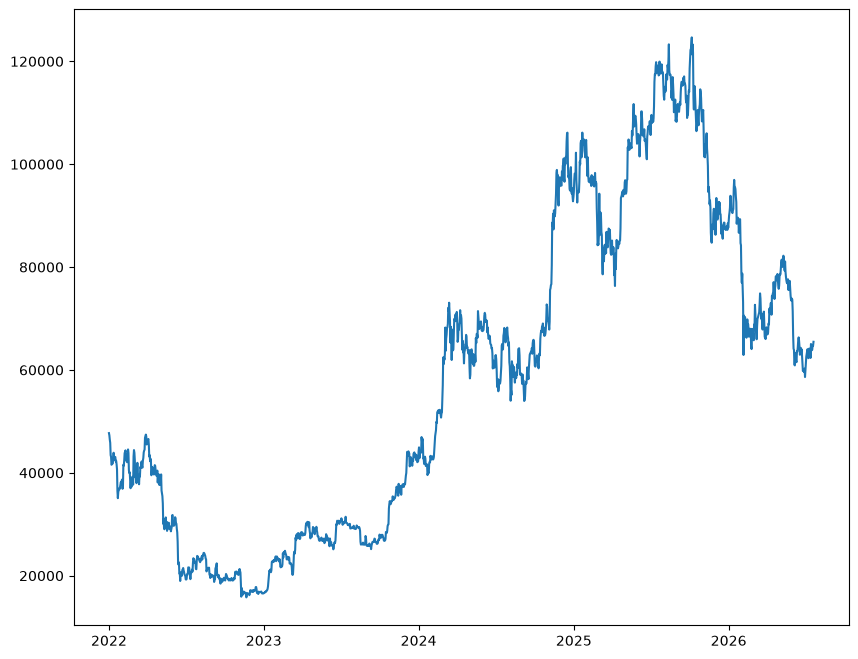

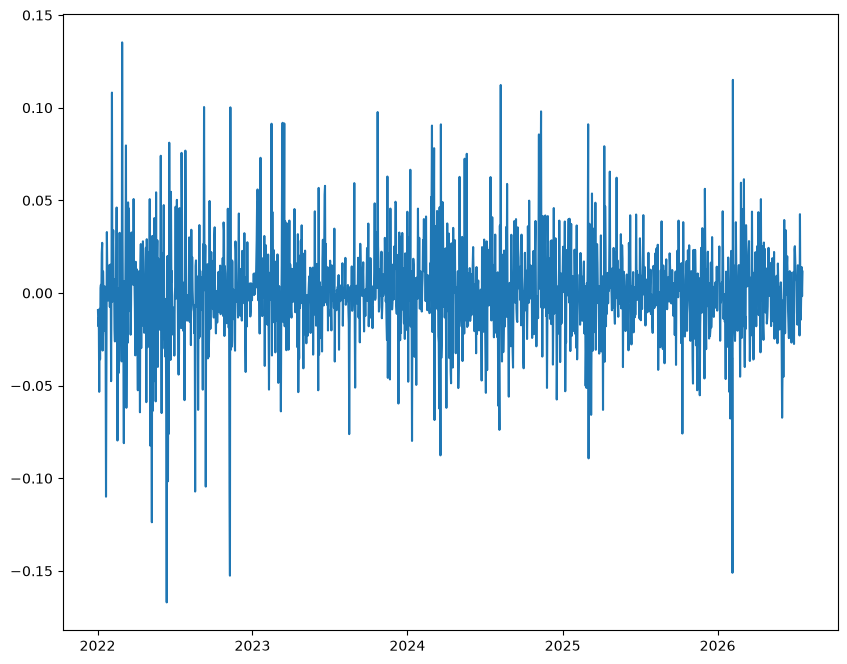

In [37]:
plt.figure(figsize=(10, 8))
plt.plot(df['date'], df['close'])

plt.figure(figsize=(10, 8))
plt.plot(df['date'], df['log_returns'])

## Zašto logaritamski prinosi umesto cena

Razlozi zašto koristimo logaritam nad prinosima ulaganja umesto čistog posmatranja cena:

### 1. Proporcionalnost

Bitna nam je proporcionalnost cena. Ukoliko Bitcoin skoči za 20%, to može biti sa \$1.000 na \$1.200 ili sa \$100.000 na \$120.000. Pošto je glavna poenta da predvidimo da li će cena skočiti gore ili dole, naivno je gledati čiste cene na kraju svakog dana. Gledanjem proporcionalnosti dobijamo formulu $\text{cena danas} / \text{cena juče}$ što nam daje multiplikator povraćaja koji bismo dobili da smo uložili juče u Bitcoin.

### 2. Aditivnost

Logaritmovanjem formule $\text{cena danas} / \text{cena juče}$ dobijemo formulu $\log(\text{cena danas}) - \log(\text{cena juče})$, čime dobijamo aditivnu pojavu umesto multiplikativne. Razlozi zašto su aditivne pojave pogodnije:

- Statistika radi sa aditivnim pojavama (srednja vrednost, centralna granična teorema, varijansa...), ne sa multiplikativnim
- Numerička stabilnost: množenje mnogo brojeva kroz vreme (pogotovo ako su decimalni) može kreirati značajne greške u računanju
- Linearni modeli (regresija, neuronske mreže) pretpostavljaju rad sa aditivnim pojavama

### 3. Domen i simetričnost

Još jedan problem sa time da ostavimo čist multiplikator povraćaja jeste što je multiplikator strogo ograničen dole (cena može najmanje pasti na nulu), a gore je neograničen (cena kriptovalute nije ograničena odozgo). Logaritam ovo rešava jer kad je odnos $\text{cena danas} / \text{cena juče}$ blizu nuli idemo ka negativnoj beskonačnosti, čime postavljamo granice raspodele da budu $(-\infty, +\infty)$. Pored ovoga, postiže se simetričnost u okviru kretanja kriptovalute, jer sada pad od 50% i skok od 100% imaju istu apsolutnu vrednost u logaritamskom prostoru.

### 4. Stacionarnost

Kroz svaki model kojim budemo testirali kretanje kriptovaluta, delićemo na trening skup i na test skup. Kako su kriptovalute podložne trendovima, to znači da se kroz vreme menja raspodela cena valuta. To znači da naš trening skup i test skup imaju dve različite raspodele, samim time nijedan model neće dati dobru procenu test vrednosti; treniramo nad podacima koji imaju jednu raspodelu, a testiramo nad podacima koji imaju drugu raspodelu. Takođe, pri evaluaciji ovakvog modela nećemo znati da li je sam model loš ili je naša obrada podataka bila loša. Stacionarnost je ovde ključna.

Slaba stacionarnost ima tri glavne komponente:

1. Konstantnu srednju vrednost kroz vreme
2. Konstantnu varijansu kroz vreme
3. Autokovarijansa $\gamma(t, k)$ zavisi samo od pomaka $k$, ne od trenutka $t$

Korišćenjem logaritama i diferenciranja pokušavamo da uvedemo stacionarnost u set podataka, mada ćemo kasnije videti da zbog određenih pojava (poput klasterizovanja volatilnosti) slaba stacionarnost nije u potpunosti zadovoljena.

0.00019041392855067275
0.02672592651647538


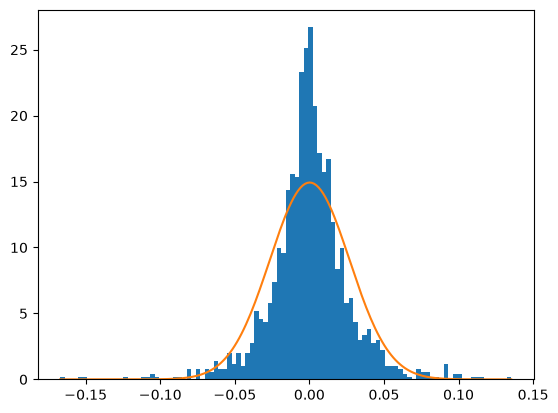

In [ ]:
#Histogram logaritamskih prinosa
plt.hist(df['log_returns'], density=True, bins=100)

#Računanje srednje vrednosti i standardne devijacije za logaritamske prinose kako bismo mogli da nacrtamo normalnu raspodelu sa tim parametrima
mean = df['log_returns'].mean()
std = df['log_returns'].std()

print(mean)
print(std)

#Crtanje normalne raspodele sa srednjom vrednošću i devijacijom koju smo izračunali
grid = np.linspace(df['log_returns'].min(), df['log_returns'].max(), 200)
plt.plot(grid, stats.norm.pdf(grid, loc=mean, scale=std))

Grafikon pokazuje da posmatrana raspodela logaritamskih prinosa značajno odstupa od normalne.

Tri stvari za primetiti:

1. Centar je previše visok: mirni dani (prinosi blizu nule) dešavaju se češće nego što normalna raspodela predviđa
2. Ramena (levo i desno od centra) su ispod linije normalne raspodele: srednje velikih kretanja ima manje nego što bi normalna očekivala
3. Daleko od centra postoje obzervacije kojima bi normalna raspodela dodelila ~0% šanse, a kod nas se javljaju u značajnom broju; tzv. teški repovi

((array([-3.34111046, -3.086476  , -2.94502628, ...,  2.94502628,
          3.086476  ,  3.34111046], shape=(1661,)),
  array([-0.16699764, -0.15256778, -0.1510256 , ...,  0.11228735,
          0.11504759,  0.13527871], shape=(1661,))),
 (np.float64(0.025899791213438387),
  np.float64(0.0001904139285506763),
  np.float64(0.9676566849169185)))

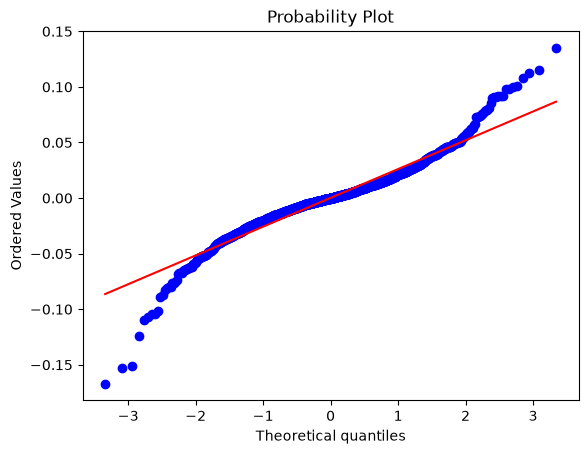

In [ ]:
#Crtamo i Q-Q dijagram kako bismo videli da li se poklapa sa našim vidjenjem raspodele logaritamskih prinosa
stats.probplot(df['log_returns'].dropna(), plot=plt)

Možemo videti ovde da se sredina raspodele logaritamskih prinosa poklapa sa normalnom raspodelom. Ali, problem nastaje kada krenemo da gledamo repove raspodele.
Konkretno, vidimo da i sa leve i sa desne strane imamo značajna odstupanja od linije koja predstavlja normalnu raspodelu. Obratimo pažnju i na to da 
levi rep ima još i veća odstupanja od desnog.

In [ ]:
#Ispisujemo normalizovani treći i četvrti momenat raspodele, kako bismo mogli da vidimo asimetričnost i spljoštenost raspodele

print(df['log_returns'].skew())
print(df['log_returns'].kurt())

#-0.19 za normalizovan treći momenat znači da je raspodela malo nagnuta ulevo, u prevodu negativne vrednosti su ekstremnije nego pozitivne što stvara levi rep koji je
#nešto deblji nego desni
#4.68 za normalizovan četvrti momenat znači da radimo sa raspodelom koja ima značajno debele repove; ova vrednost kod normalne raspodele je 
#jednaka nuli

-0.19019698479194508
4.678577072959937


Sada je vreme da proverimo da li naše posmatrane vrednosti imaju korelaciju sa sopstvenim istorijskim podacima. Koristićemo ACF (autokorelacionu funkciju) kako bismo pre svega proverili da li postoji linearna veza izmedju ranijih i sadašnjih vrednosti u okviru logaritamskih prinosa. Odmah posle toga ćemo uraditi i Ljung-Box test radi provere da li rezultati autokorelacione funkcije zaista ne daju bilo kakvu linearnu zavisnost koju možemo iskoristiti već predstavljaju tzv. white noise.

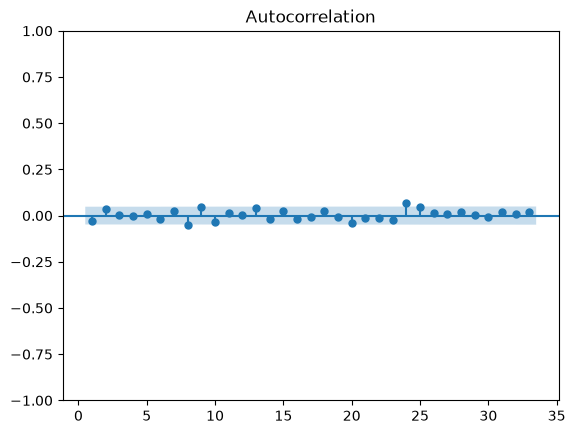

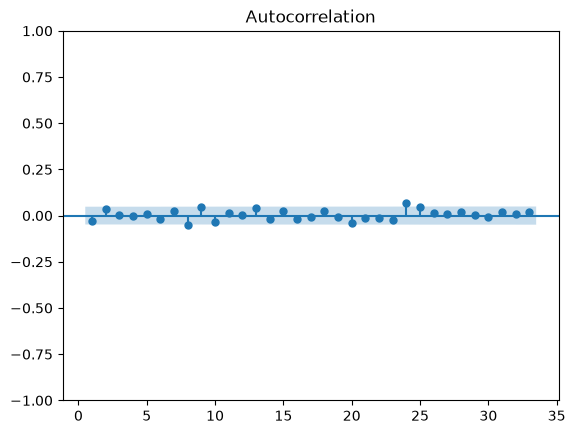

In [72]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

plot_acf(df['log_returns'].dropna(), zero=False)

Na grafikonu možemo videti da vrednost ACF funkcije gravitira oko nule. Iako su vrednosti funkcije male, ne znači da ih automatski treba odbaciti. Zato se radi Ljung-Box test koji će nam reći da li ipak postoji neka, makar mala, linearna zavisnost.

In [71]:
ljung_box_df1 = acorr_ljungbox(df['log_returns'].dropna(), lags=20)
print(ljung_box_df1)

      lb_stat  lb_pvalue
1    1.221702   0.269027
2    3.146615   0.207358
3    3.183594   0.364176
4    3.187232   0.526996
5    3.355850   0.645302
6    3.938872   0.684949
7    5.063442   0.652221
8    9.239540   0.322494
9   12.541713   0.184463
10  14.367371   0.156884
11  14.600944   0.201504
12  14.653021   0.260962
13  17.253012   0.187994
14  17.938047   0.209617
15  19.183710   0.205529
16  19.810040   0.228898
17  19.979797   0.275264
18  21.158608   0.271487
19  21.255480   0.322858
20  23.964645   0.243940


U okviru kolone lb_pvalue možemo videti da je svaka p vrednost daleko iznad 0,05 praga. Samim time možemo zaključiti da vrednosti u okviru ACF funkcije zaista predstavljaju white noise.

Ali, to što ne postoji linearna zavisnost ne znači da ne postoji nelinearna. Sledeći korak nam je crtanje autokorelacione funkcije za kvadrate logaritamskih prinosa i posmatranje potencijalne medjuzavisnosti izmedju istorijskih i sadašnjih podataka.

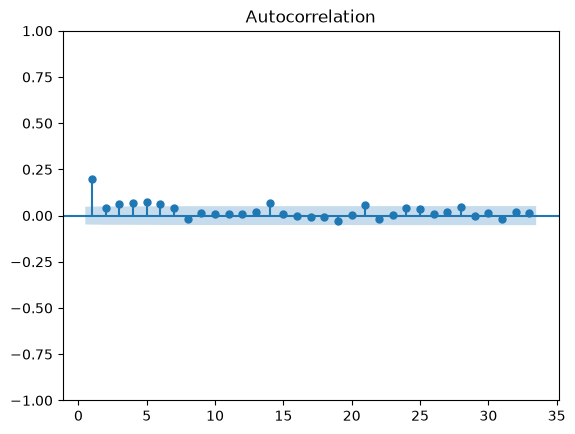

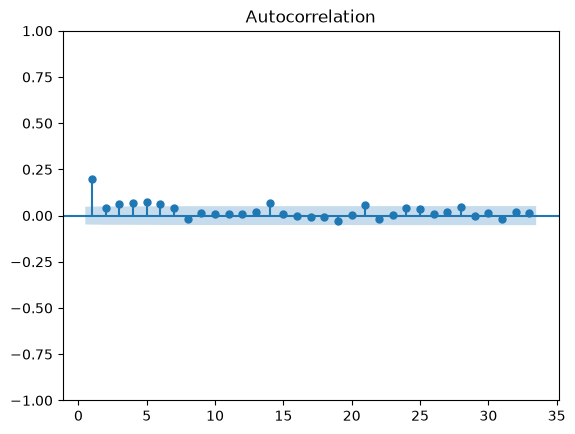

In [74]:
plot_acf(df['log_returns'].dropna() ** 2, zero=False)

Posmatrane vrednosti, makar na početku, zapravo daju neku autokorelaciju koja je iznad nule (autokorelacija je jednaka 0.25 kad posmatramo današnji dan u odnosu na jučerašnji). Iako vrednosti funkcije nisu izrazito velike, ne znači da se treba odbaciti. Shodno tome ćemo ponoviti Ljung-Box test kako bismo proverili p-vrednosti radi provere da li iz kvadrata logaritamskih prinosa može da se izvuče neka medjuzavisnost

In [75]:
ljung_box_df2 = acorr_ljungbox(df['log_returns'].dropna() ** 2, lags=20)
print(ljung_box_df2)

       lb_stat     lb_pvalue
1    64.292835  1.072350e-15
2    67.461163  2.243854e-15
3    74.074405  5.720974e-16
4    82.037139  6.446187e-17
5    91.413948  3.390189e-18
6    97.845118  7.062208e-19
7   100.422281  8.825229e-19
8   100.913881  2.776565e-18
9   101.379108  8.275542e-18
10  101.552933  2.663028e-17
11  101.678489  8.302650e-17
12  101.802789  2.467136e-16
13  102.481478  5.474176e-16
14  110.713434  4.067933e-17
15  110.851525  1.106465e-16
16  110.863227  3.073403e-16
17  110.917095  8.109243e-16
18  110.986878  2.060909e-15
19  112.248018  3.066027e-15
20  112.248431  7.627530e-15


Kao što možemo videti, sve p-vrednosti su praktično jednake nuli. To potvrđuje da kvadrati logaritamskih prinosa imaju autokorelaciju: postoji struktura u intenzitetu kretanja (klasterizovanje volatilnosti), za razliku od samog smera kretanja, koji je prethodno pokazao osobine belog šuma.

Ova struktura sama po sebi ne govori ništa o smeru: velika kretanja se grupišu, ali ne znamo da li naviše ili naniže. Ipak, ova pojava inspiriše korišćenje obeležja zasnovanih na volatilnosti u kasnijem modelovanju. Da li se ta struktura može iskoristiti za predviđanje smera ostaje pitanje koje ćemo ispitati u narednim koracima.